In [44]:
# Polymarket Test
from src.handlers.polymarket import PolymarketHandler
from src.utils.utils import *
from dotenv import load_dotenv
import psycopg2
from psycopg2 import OperationalError
import copy
import requests
from datetime import datetime
from huggingface_hub import list_repo_files, hf_hub_download, login
import pprint
import time
import duckdb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

import os

# Load environment variables
load_dotenv()

# Make a PolymarketHandler instance
polymarketHandler = PolymarketHandler(
    polymarketAPIkey = os.getenv("polymarketAPI_key"),
    web3APIkey = os.getenv("alchemyAPI_key"),
    provider = "alchemy"
)


In [2]:
df = pd.DataFrame(queryParquetFile("src/data/polymarketData/polymarket_trades_pt_018.parquet", "SELECT * FROM data "))
df.columns

Index(['block_number', 'block_timestamp', 'tx_hash', 'platform_name',
       'platform_version', 'taker', 'maker', 'token_id', 'slug',
       'condition_id', 'price', 'taker_side', 'amount', 'amount_asset', 'fee',
       'fee_asset', 'extra_data'],
      dtype='str')

In [ ]:
tmp = pd.DataFrame(queryParquetFile("src/data/polymarketData/polymarket_trades_pt_019.parquet", "SELECT * FROM data LIMIT 1"))
tmp.columns

Index(['block_number', 'block_timestamp', 'tx_hash', 'platform_name',
       'platform_version', 'taker', 'maker', 'token_id', 'slug',
       'condition_id', 'price', 'taker_side', 'amount', 'amount_asset', 'fee',
       'fee_asset', 'extra_data'],
      dtype='str')

In [ ]:
_max = pd.DataFrame(queryParquetFile("src/data/polymarketData/polymarket_trades_pt_018.parquet", "SELECT MAX(block_timestamp) AS largest_value FROM data")).iloc[0,0]
_min = pd.DataFrame(queryParquetFile("src/data/polymarketData/polymarket_trades_pt_019.parquet", "SELECT MIN(block_timestamp) AS largest_value FROM data")).iloc[0,0]
print("time difference with prev batch:", (_min-_max)/60/24, "days")

_max = pd.DataFrame(queryParquetFile("src/data/polymarketData/polymarket_trades_pt_018.parquet", "SELECT MAX(block_number) AS largest_value FROM data")).iloc[0,0]
_min = pd.DataFrame(queryParquetFile("src/data/polymarketData/polymarket_trades_pt_019.parquet", "SELECT MIN(block_number) AS largest_value FROM data")).iloc[0,0]
print("block difference with prev batch:", (_min-_max), "blocks")

_min = pd.DataFrame(queryParquetFile("src/data/polymarketData/polymarket_trades_pt_019.parquet", "SELECT MIN(block_timestamp) AS largest_value FROM data")).iloc[0,0]
_max = pd.DataFrame(queryParquetFile("src/data/polymarketData/polymarket_trades_pt_019.parquet", "SELECT MAX(block_timestamp) AS largest_value FROM data")).iloc[0,0]
print("time difference:", (_max-_min)/60/24, "days")

_min = pd.DataFrame(queryParquetFile("src/data/polymarketData/polymarket_trades_pt_019.parquet", "SELECT MIN(block_number) AS largest_value FROM data")).iloc[0,0]
_max = pd.DataFrame(queryParquetFile("src/data/polymarketData/polymarket_trades_pt_019.parquet", "SELECT MAX(block_number) AS largest_value FROM data")).iloc[0,0]
print("block difference:", (_max-_min), "blocks")

time difference with prev batch: 0.001388888888888889 days
block difference with prev batch: 1 blocks
time difference: 17.77638888888889 days
block difference: 12799 blocks


In [33]:
allMarkets = pd.DataFrame(queryParquetFile("src/data/polymarket_HistoricalMarkets.parquet", "SELECT * FROM data"))

In [48]:

def plotOutcomes(dfs, labels=None, title="Price Comparison", figsize=(12, 6)):

    """
    Plots price data from an arbitrary number of dataframes on a single plot.

    Parameters:
        dfs : list of pd.DataFrame
            Each must have 'block_timestamp' and 'price' columns.
        labels : list of str, optional
            Legend labels for each series. Defaults to "Series 1", "Series 2", ...
        title : str
            Plot title.
        figsize : tuple
            Figure size.
    """
    if labels is None:
        labels = [f"Series {i+1}" for i in range(len(dfs))]
    elif len(labels) != len(dfs):
        raise ValueError("Length of labels must match length of dfs")

    fig, ax = plt.subplots(figsize=figsize)

    for df, label in zip(dfs, labels):
        df = df.copy()
        df["block_timestamp"] = pd.to_datetime(df["block_timestamp"], unit = "s")
        df = df.sort_values("block_timestamp")
        ax.plot(df["block_timestamp"], df["price"], label=label, linewidth=1.5)

    ax.set_xlabel("Time")
    ax.set_ylabel("Price")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Human-readable date formatting
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d, %Y"))
    # If your data spans hours/minutes rather than days, swap the formatter for:
    # mdates.DateFormatter("%b %d, %Y %H:%M")

    fig.autofmt_xdate()  # rotates labels so they don't overlap
    plt.tight_layout()
    plt.show()

    return fig, ax

In [ ]:
allMarkets[allMarkets.slug.duplicated()]

In [15]:
# Plot a polymarket's market 

# Get the market's data - one token ID has to be given
tokenID = "930700082299559062125948884729581988641930245091222204337103918093932025333"
marketData = pd.DataFrame(queryParquetFile("src/data/polymarket_HistoricalMarkets.parquet", f"SELECT * FROM data WHERE outcome_0_ID = '{tokenID}' OR  outcome_1_ID = '{tokenID}'"))

outcome_0_trades = queryParquetFolder("./src/data/polymarketData", f"SELECT * FROM data WHERE token_id = '{marketData.iloc[0].outcome_0_ID}'")
outcome_1_trades = queryParquetFolder("./src/data/polymarketData", f"SELECT * FROM data WHERE token_id = '{marketData.iloc[0].outcome_1_ID}'")

print(f"Slug: {marketData.iloc[0].slug}")
print(f"Market ID: {marketData.iloc[0].marketID}")
print(f"Outcome 0: {marketData.iloc[0].outcome_0} ({marketData.iloc[0].outcome_0_ID[0:10]}...)")
print(f"Outcome 1: {marketData.iloc[0].outcome_1} ({marketData.iloc[0].outcome_1_ID[0:10]}...)")
print(f"Total trades count: {outcome_0_trades.shape[0] + outcome_1_trades.shape[0]:,}")
# print(f"Duration: {(allTrades.iloc[-1].block_timestamp - allTrades.iloc[0].block_timestamp)/60/24}")


Slug: atp-travagl-jong-2026-04-28
Market ID: 2089491
Outcome 0: Stefano Travaglia (9307000822...)
Outcome 1: Jesper de Jong (6920541301...)
Total trades count: 600


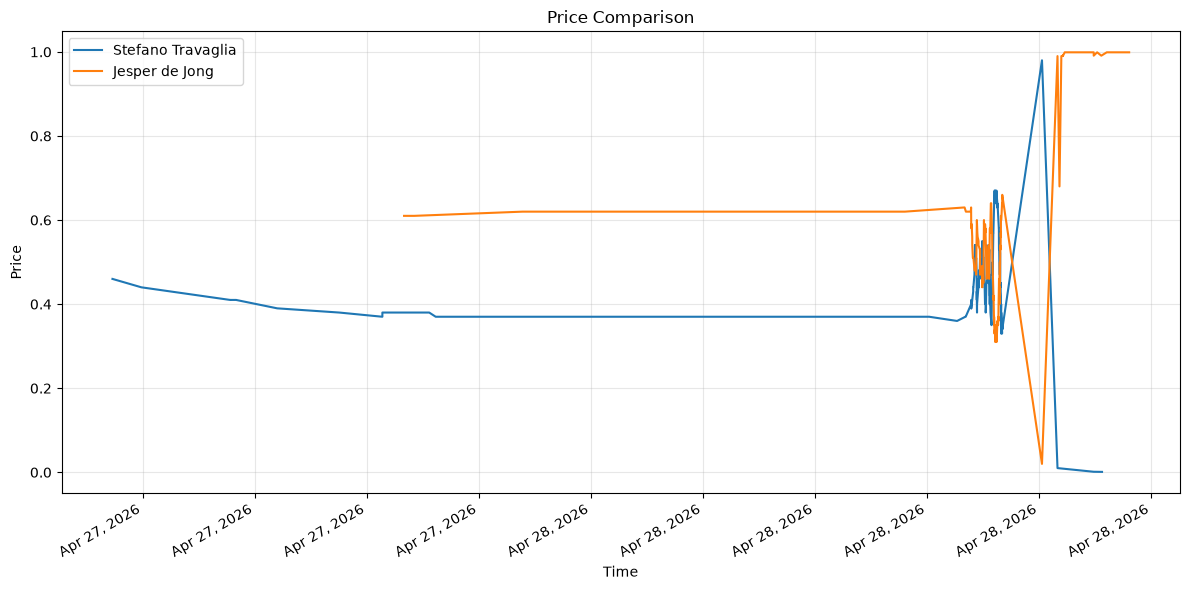

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Price Comparison'}, xlabel='Time', ylabel='Price'>)

In [49]:
plotOutcomes(
    [outcome_0_trades, outcome_1_trades],
    [marketData.iloc[0].outcome_0, marketData.iloc[0].outcome_1]
)